<a href="https://colab.research.google.com/github/your-repo/knowledge_graph_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# PyTorch Knowledge Graph Analysis

This notebook provides tools to explore and analyze the enhanced PyTorch knowledge graph with granular function and variable information.

In [1]:
# Import required libraries
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import os

# Set up plotting style
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

print("Knowledge Graph Analysis Tools Loaded")

Knowledge Graph Analysis Tools Loaded


In [2]:
# Load the enhanced knowledge graph
def load_knowledge_graph(file_path="codebase_knowledge_graph_torch_enhanced.json"):
    """
    Load the enhanced knowledge graph from JSON file
    """
    if not os.path.exists(file_path):
        raise FileNotFoundError(f"Knowledge graph file {file_path} not found. Please ensure the file exists.")
    
    with open(file_path, 'r') as f:
        graph = json.load(f)
    
    print(f"Loaded knowledge graph with {len(graph['nodes'])} nodes")
    print(f"Metadata: {graph['metadata']}")
    
    return graph

# Load the graph
try:
    knowledge_graph = load_knowledge_graph()
    nodes = knowledge_graph['nodes']
    print(f"Successfully loaded {len(nodes)} nodes from knowledge graph")
except Exception as e:
    print(f"Error loading knowledge graph: {e}")

Loaded knowledge graph with 153397 nodes
Metadata: {'total_node_count': 153397, 'enhancement_date': '2026-03-04', 'description': 'Enhanced knowledge graph with individual functions and variables from PyTorch torch/ directory', 'source': 'Extracted from PyTorch torch/ directory using AST parsing', 'scope': 'torch directory only'}
Successfully loaded 153397 nodes from knowledge graph


In [3]:
# Basic exploration functions
def get_node_types(nodes):
    """
    Get counts of different node types
    """
    type_counts = Counter(node['type'] for node in nodes)
    return type_counts

def get_top_files(nodes, top_n=10):
    """
    Get top files by number of nodes
    """
    file_counts = Counter(node['path'] for node in nodes)
    return file_counts.most_common(top_n)

def get_top_functions_by_name(nodes, top_n=10):
    """
    Get top function names by frequency
    """
    func_names = [node['name'] for node in nodes if node['type'] == 'function']
    name_counts = Counter(func_names)
    return name_counts.most_common(top_n)

# Display basic statistics
print("=== Knowledge Graph Statistics ===")
node_types = get_node_types(nodes)
print(f"Node types distribution:")
for node_type, count in node_types.items():
    print(f"  {node_type}: {count}")

print(f"\nTop 5 files by node count:")
top_files = get_top_files(nodes, 5)
for file, count in top_files:
    print(f"  {file}: {count}")

=== Knowledge Graph Statistics ===
Node types distribution:
  class: 5223
  variable: 104967
  function: 43207

Top 5 files by node count:
  torch/testing/_internal/common_methods_invocations.py: 2374
  torch/testing/_internal/distributed/distributed_test.py: 2113
  torch/_inductor/ir.py: 1783
  torch/_inductor/lowering.py: 1574
  torch/testing/_internal/distributed/rpc/rpc_test.py: 1490


In [4]:
# Create a DataFrame for easier analysis
def create_dataframe(nodes):
    """
    Create a pandas DataFrame from the nodes for easier analysis
    """
    df = pd.DataFrame(nodes)
    return df

# Create DataFrame
df = create_dataframe(nodes)
print("DataFrame created with shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nFirst few rows:")
print(df.head())

DataFrame created with shape: (153397, 6)

Columns: ['id', 'name', 'type', 'path', 'line', 'description']

First few rows:
                         id         name      type                 path  line  \
0     torch/_VF.py:VFModule     VFModule     class         torch/_VF.py    20   
1           torch/_VF.py:vf           vf  variable         torch/_VF.py    21   
2     torch/_VF.py:__init__     __init__  function         torch/_VF.py    23   
3  torch/_VF.py:__getattr__  __getattr__  function         torch/_VF.py    27   
4  torch/__config__.py:show         show  function  torch/__config__.py     4   

                                         description  
0                                                     
1                              Annotated variable vf  
2                                                     
3                                                     
4  Return a human-readable string with descriptio...  


=== Node Type Analysis ===
type
variable    104967
function     43207
class         5223
Name: count, dtype: int64


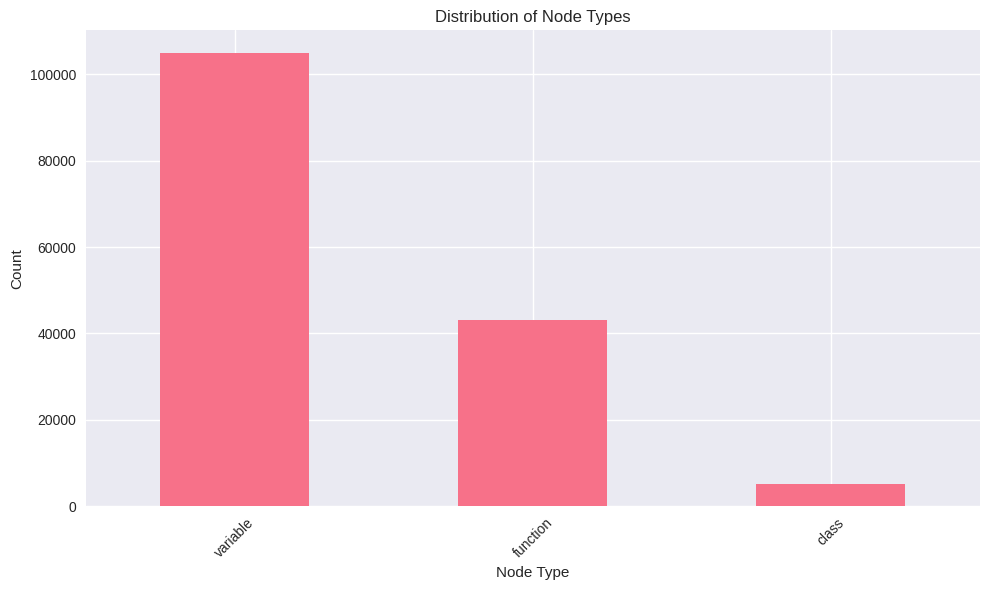

In [5]:
# Analyze node types
print("=== Node Type Analysis ===")
type_analysis = df['type'].value_counts()
print(type_analysis)

# Plot node type distribution
plt.figure(figsize=(10, 6))
type_analysis.plot(kind='bar')
plt.title('Distribution of Node Types')
plt.xlabel('Node Type')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [6]:
# Search functions and variables
def search_nodes(df, search_term, column='name'):
    """
    Search for nodes containing a term
    """
    results = df[df[column].str.contains(search_term, case=False, na=False)]
    return results

def search_by_path(df, path_term):
    """
    Search for nodes by path
    """
    results = df[df['path'].str.contains(path_term, case=False, na=False)]
    return results

# Example searches
print("=== Search Examples ===")

# Search for 'tensor' related functions
tensor_results = search_nodes(df, 'tensor')
print(f"Found {len(tensor_results)} nodes containing 'tensor'")
print(tensor_results[['name', 'type', 'path']].head(10))

# Search for a specific function
print("\nSearching for 'forward' function:")
forward_results = search_nodes(df, 'forward')
print(f"Found {len(forward_results)} nodes containing 'forward'")
print(forward_results[['name', 'type', 'path']].head(10))

=== Search Examples ===
Found 4543 nodes containing 'tensor'
                        name      type                    path
36                 is_tensor  function       torch/__init__.py
41   set_default_tensor_type  function       torch/__init__.py
59    _check_tensor_all_with  function       torch/__init__.py
60         _check_tensor_all  function       torch/__init__.py
80           _tensor_classes  variable       torch/__init__.py
103      _as_tensor_fullprec  function       torch/__init__.py
765             fake_tensors  variable        torch/_guards.py
838         _TensorExtractor     class  torch/_jit_internal.py
839         _extract_tensors  function  torch/_jit_internal.py
928                  tensors  variable  torch/_jit_internal.py

Searching for 'forward' function:
Found 1071 nodes containing 'forward'
                                         name      type  \
1040                                  forward  function   
1349                      meta__pdist_forward  function

In [7]:
# Analyze specific file paths
def analyze_file_path(df, file_path):
    """
    Analyze nodes from a specific file path
    """
    file_nodes = df[df['path'] == file_path]
    print(f"Nodes from {file_path}:")
    print(f"Total: {len(file_nodes)} nodes")
    print(f"Types: {file_nodes['type'].value_counts()}")
    
    if len(file_nodes) > 0:
        print("\nFirst 10 nodes:")
        print(file_nodes[['name', 'type', 'line']].head(10))
    
    return file_nodes

# Example: Analyze a specific file
print("=== File Analysis ===")
example_file = 'torch/nn/modules/module.py'
file_analysis = analyze_file_path(df, example_file)

=== File Analysis ===
Nodes from torch/nn/modules/module.py:
Total: 307 nodes
Types: type
variable    207
function     97
class         3
Name: count, dtype: int64

First 10 nodes:
                                        name      type  line
119222                               __all__  variable    21
119223                               _grad_t  variable    33
119224                                     T  variable    37
119225                     _IncompatibleKeys     class    40
119226                            _addindent  function    54
119227     _global_buffer_registration_hooks  variable    69
119228     _global_module_registration_hooks  variable    70
119229  _global_parameter_registration_hooks  variable    71
119230                          _WrappedHook     class    74
119231            _global_backward_pre_hooks  variable   116


In [8]:
# Function to get detailed information about a specific node
def get_node_details(df, node_id):
    """
    Get detailed information about a specific node by ID
    """
    node = df[df['id'] == node_id]
    if len(node) > 0:
        return node.iloc[0]
    else:
        return None

# Example: Get details of a specific node
print("=== Node Details ===")
sample_node_id = 'torch/nn/modules/module.py:forward'
node_details = get_node_details(df, sample_node_id)

if node_details is not None:
    print("Node Details:")
    for key, value in node_details.items():
        print(f"  {key}: {value}")
else:
    print(f"Node with ID {sample_node_id} not found")

=== Node Details ===
Node Details:
  id: torch/nn/modules/module.py:forward
  name: forward
  type: variable
  path: torch/nn/modules/module.py
  line: 526
  description: Annotated variable forward


In [9]:
# Export functionality
def export_search_results(results_df, filename='search_results.csv'):
    """
    Export search results to CSV
    """
    results_df.to_csv(filename, index=False)
    print(f"Results exported to {filename}")

# Example: Export some search results
print("=== Export Example ===")
tensor_functions = search_nodes(df, 'tensor', 'name')
export_search_results(tensor_functions, 'tensor_functions.csv')

print(f"\nExported {len(tensor_functions)} tensor-related functions to CSV")

=== Export Example ===
Results exported to tensor_functions.csv

Exported 4543 tensor-related functions to CSV


In [10]:
# Summary statistics
print("=== Knowledge Graph Summary ===")
print(f"Total nodes: {len(nodes)}")
print(f"Unique files: {df['path'].nunique()}")
print(f"Unique node types: {df['type'].nunique()}")
print(f"Node types: {df['type'].unique()}")

# Top 10 most common function names
print("\nTop 10 most common function names:")
func_names = df[df['type'] == 'function']['name'].value_counts().head(10)
for name, count in func_names.items():
    print(f"  {name}: {count}")

=== Knowledge Graph Summary ===
Total nodes: 153397
Unique files: 1972
Unique node types: 3
Node types: ['class' 'variable' 'function']

Top 10 most common function names:
  __init__: 2654
  forward: 651
  __repr__: 300
  __call__: 285
  wrapper: 189
  __str__: 169
  __exit__: 141
  __enter__: 138
  __eq__: 121
  create: 107
